In [1]:
#lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD & CLEAN DATA

In [2]:
df_spend = pd.read_parquet('marketing_spend.parquet')
df_trans = pd.read_parquet('customer_transactions.parquet')

In [3]:
# ตรวจสอบข้อมูลที่หายไป & คอลลั่ม
print(df_trans.notna().all(),'\n','\n',
      df_spend.notna().all()
 )

customer_id       True
order_date        True
amount            True
channel_origin    True
dtype: bool 
 
 date       True
channel    True
spend      True
clicks     True
dtype: bool


# Total spend & ROI


In [38]:
#groupby 

df_spend.groupby('channel').agg({'spend':'sum'}).reset_index(),

df_trans.groupby('channel_origin').agg({'amount':'sum'}).reset_index(),

Total_spend = pd.merge(df_spend.groupby('channel').agg({'spend':'sum'}).reset_index(),
                        df_trans.groupby('channel_origin').agg({'amount':'sum'}).reset_index(),
                        left_on='channel', right_on='channel_origin', how='right').drop(columns=['channel_origin'])   

Total_spend['margin'] = Total_spend['amount'] - Total_spend['spend']

Total_spend = Total_spend.sort_values(by='margin', ascending=False)

Total_spend['percentage_margin'] = (Total_spend['margin'] / Total_spend['amount'])*100    


In [39]:
## rename columns and round values
Total_spend.rename(columns={
    'channel':'channel',
    'spend':'total_spend',
    'amount':'total_amount'
}, inplace=True)

Total_spend[['total_spend','total_amount','margin','percentage_margin']] = round(Total_spend[['total_spend','total_amount','margin','percentage_margin']],ndigits=2)

Total_spend['ROI_Ratio_NetProfit'] = round ((Total_spend['margin'] / Total_spend['total_spend']),ndigits=2) 

C:\Users\patta\AppData\Local\Temp\ipykernel_9312\3971640436.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Total_spend, x ='channel', y ='ROI_Ratio_NetProfit', palette='viridis')


(0.0, 1.97)

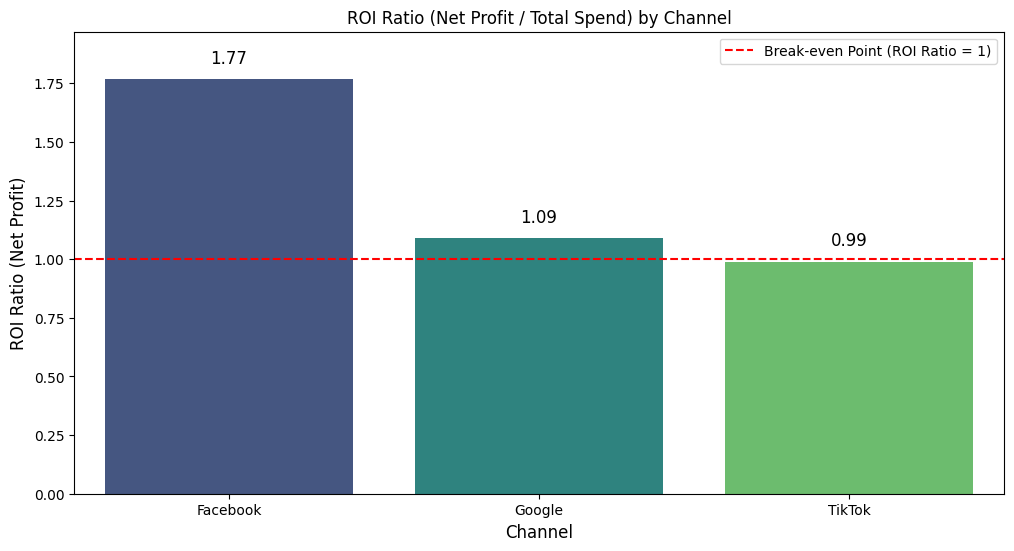

In [40]:
Total_spend.sort_values('ROI_Ratio_NetProfit', ascending=False)
#Visualization

plt.figure(figsize=(12,6))
sns.barplot(data=Total_spend, x ='channel', y ='ROI_Ratio_NetProfit', palette='viridis')
plt.axhline(1, color='red', linestyle='--' , label= 'Break-even Point (ROI Ratio = 1)')
plt.title('ROI Ratio (Net Profit / Total Spend) by Channel')
plt.ylabel('ROI Ratio (Net Profit)', fontsize=12)
plt.xlabel('Channel', fontsize=12)

# Add value labels on top of the bars
for index, value in enumerate(Total_spend['ROI_Ratio_NetProfit']):
    plt.text(index, value + 0.05, f'{value:.2f}', ha='center', va='bottom', fontsize=12 , color='black' )
plt.legend()
plt.ylim(0, Total_spend['ROI_Ratio_NetProfit'].max() + 0.2)  # เพิ่มพื้นที่ด้านบนของกราฟเพื่อให้เห็นค่า ROI Ratio ชัดเจนขึ้น

EDA


In [41]:
#EDA tread amount by date
df_trans.to_csv('customer_transactions_for_eda.csv', index=False)

# Transaction Customer


In [42]:
df_trans.columns

Index(['customer_id', 'order_date', 'amount', 'channel_origin'], dtype='object')

In [43]:
#groupby customer_id sum amount and count customer_id & Rename columns
group_csid = df_trans.groupby('customer_id').agg(
    {'amount':'sum', 'customer_id' : 'count'}
    ).sort_values('amount', ascending=False) 

group_csid.rename(columns={
    'amount':'total_amount',
    'customer_id':'transaction_count'
}, inplace=True)

group_csid

,total_amount,transaction_count
customer_id,,
10545,6798.301264,5
12722,6328.171630,3
11269,6213.552082,4
12686,6148.010842,5
11673,5448.349561,4
...,...,...
13343,1.755410,1
12866,0.937250,1
14574,0.277169,1


In [44]:
#make total_amount and average_amount
group_csid['total_amount'] =round(group_csid['total_amount'],ndigits=2)
group_csid['AVG_amount'] = round(group_csid['total_amount'] / group_csid['transaction_count'],ndigits=2)

#make LTV(Lifetime Value) = Average Purchase Value x Purchase Frequency x 2 years
group_csid['LTVper2years'] = round(group_csid['AVG_amount'] * group_csid['transaction_count'] * 2,ndigits=2)

In [45]:
group_csid

,total_amount,transaction_count,AVG_amount,LTVper2years
customer_id,,,,
10545,6798.30,5,1359.66,13596.60
12722,6328.17,3,2109.39,12656.34
11269,6213.55,4,1553.39,12427.12
12686,6148.01,5,1229.60,12296.00
11673,5448.35,4,1362.09,10896.72
...,...,...,...,...
13343,1.76,1,1.76,3.52
12866,0.94,1,0.94,1.88
14574,0.28,1,0.28,0.56


In [46]:
group_csid.describe()

,total_amount,transaction_count,AVG_amount,LTVper2years
count,3148.000000,3148.00000,3148.000000,3148.000000
mean,801.569228,1.58831,504.811916,1603.138640
std,784.513463,0.83353,453.696123,1569.027094
min,0.080000,1.00000,0.080000,0.160000
25%,235.610000,1.00000,184.610000,471.220000
50%,567.575000,1.00000,391.120000,1135.150000
75%,1124.432500,2.00000,681.757500,2248.850000
max,6798.300000,7.00000,3381.750000,13596.600000


## Start Segment

In [47]:
#RFM Summary
from pymc_marketing.clv.utils import rfm_summary

df_churn_model_auto = rfm_summary(df_trans,
                customer_id_col='customer_id',
                datetime_col='order_date',
                monetary_value_col='amount',
                observation_period_end=df_trans['order_date'].max()
            )

In [48]:
# make LTV 
df_churn_model_auto['frequency_plus_one']= df_churn_model_auto['frequency'] + 1
df_churn_model_auto['LTV']=df_churn_model_auto['frequency_plus_one'] * df_churn_model_auto['monetary_value'] * df_churn_model_auto['T'] / 360 

In [49]:
df_churn_model_auto

,customer_id,frequency,recency,T,monetary_value,frequency_plus_one,LTV
0,10001,0.0,0.0,277.0,0.000000,1.0,0.000000
1,10002,0.0,0.0,322.0,0.000000,1.0,0.000000
2,10004,0.0,0.0,22.0,0.000000,1.0,0.000000
3,10007,0.0,0.0,272.0,0.000000,1.0,0.000000
4,10011,0.0,0.0,216.0,0.000000,1.0,0.000000
...,...,...,...,...,...,...,...
3143,14992,1.0,5.0,139.0,432.822615,2.0,334.235242
3144,14994,3.0,263.0,310.0,278.808408,4.0,960.340072
3145,14995,0.0,0.0,169.0,0.000000,1.0,0.000000
3146,14996,0.0,0.0,284.0,0.000000,1.0,0.000000


In [50]:
#merge group

group_csid = pd.merge(group_csid , df_churn_model_auto[['customer_id' , 'LTV']] , on = 'customer_id' , how= 'left')

Text(0.5, 1.0, 'Elbow Method')

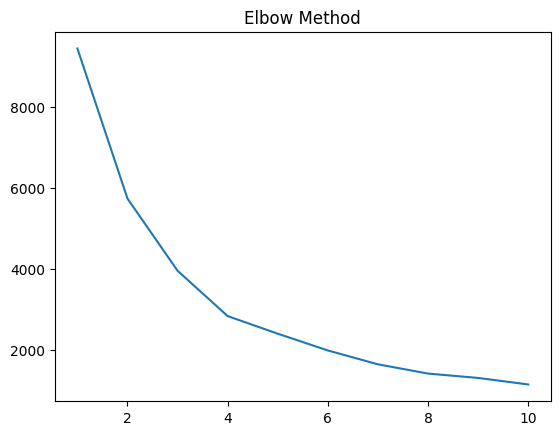

In [51]:
#Elbow method
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans  
import matplotlib.pyplot as plt
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    X = group_csid[['AVG_amount','transaction_count','LTV']]
    X = StandardScaler().fit_transform(X)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)    
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')

In [52]:
# silhouette score
from sklearn.metrics import silhouette_score

for k in range(2, 8): # เช็คแค่ 2 ถึง 5 clusters
    model = KMeans(n_clusters=k, random_state=42).fit(X)
    score = silhouette_score(X, model.labels_)
    print(f"K={k}, Silhouette Score: {score:.4f}")

K=2, Silhouette Score: 0.4913
K=3, Silhouette Score: 0.4842
K=4, Silhouette Score: 0.4975
K=5, Silhouette Score: 0.4926
K=6, Silhouette Score: 0.4931
K=7, Silhouette Score: 0.5122


สรุปใช้ที่ 4 cluster  ค่า silhouette เข้าใกล้ 1 มากพอสมควร และไม่ลำบากเกินไปในการจัดกลุ่ม

หาจำนวนกลุ่ม (K) แบบมาตรฐาน	Elbow Method (Mean-based)	ง่าย รวดเร็ว และเป็นมาตรฐานที่คนทั่วไปเข้าใจได้ทันที

ถ้ากราฟ Elbow ดูยาก (ไม่มีมุมหักชัดเจน)	Silhouette Score	ใช้เช็คว่า Cluster ทับซ้อนกันไหม (แม่นยำกว่า Elbow ในหลายกรณี)

ถ้าไม่อยากเดา K เองเลย	Bayesian GMM	ให้อัลกอริทึมคำนวณ "น้ำหนัก" และตัดสินใจจำนวนกลุ่มให้เอง



In [53]:
#cluster K means

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
group_csid['cluster'] = kmeans.labels_  
group_csid.sort_values(by=['cluster'], ascending=False)    



,customer_id,total_amount,transaction_count,AVG_amount,LTVper2years,LTV,cluster
3147,11890,0.08,1,0.08,0.16,0.0,3
3146,10752,0.15,1,0.15,0.30,0.0,3
3145,14574,0.28,1,0.28,0.56,0.0,3
3144,12866,0.94,1,0.94,1.88,0.0,3
3143,13343,1.76,1,1.76,3.52,0.0,3
...,...,...,...,...,...,...,...
443,12541,1571.98,1,1571.98,3143.96,0.0,0
426,14570,1607.37,1,1607.37,3214.74,0.0,0
425,14019,1608.54,1,1608.54,3217.08,0.0,0
424,10684,1608.65,1,1608.65,3217.30,0.0,0


In [54]:
#map

segmentation_map = {
    0: 'Gold (Mid-High Value)',
    1: 'Silver (Mid value)',
    2: 'Platinum (High Value)',
    3 :'Bronze (Loe Value)'
    }

group_csid['segment'] = group_csid['cluster'].map(segmentation_map)

In [55]:
group_csid

,customer_id,total_amount,transaction_count,AVG_amount,LTVper2years,LTV,cluster,segment
0,10545,6798.30,5,1359.66,13596.60,2824.964199,2,Platinum (High Value)
1,12722,6328.17,3,2109.39,12656.34,2337.547085,2,Platinum (High Value)
2,11269,6213.55,4,1553.39,12427.12,5529.674655,2,Platinum (High Value)
3,12686,6148.01,5,1229.60,12296.00,5061.185573,2,Platinum (High Value)
4,11673,5448.35,4,1362.09,10896.72,5283.129011,2,Platinum (High Value)
...,...,...,...,...,...,...,...,...
3143,13343,1.76,1,1.76,3.52,0.000000,3,Bronze (Loe Value)
3144,12866,0.94,1,0.94,1.88,0.000000,3,Bronze (Loe Value)
3145,14574,0.28,1,0.28,0.56,0.000000,3,Bronze (Loe Value)
3146,10752,0.15,1,0.15,0.30,0.000000,3,Bronze (Loe Value)


ตั้งชื่อให้แต่ละ segment

In [56]:
group_csid.groupby('segment').agg({
    'total_amount' : ['sum' , 'count','mean'],
})


total_amount                   
                               sum count         mean
segment                                              
Bronze (Loe Value)       443830.12  1477   300.494326
Gold (Mid-High Value)    556202.90   383  1452.226893
Platinum (High Value)    691507.40   307  2252.467101
Silver (Mid value)       831799.51   981   847.909796

In [57]:
group_csid['segment'].value_counts()

segment
Bronze (Loe Value)       1477
Silver (Mid value)        981
Gold (Mid-High Value)     383
Platinum (High Value)     307
Name: count, dtype: int64

In [58]:
group_csid.describe()

,customer_id,total_amount,transaction_count,AVG_amount,LTVper2years,LTV,cluster
count,3148.000000,3148.000000,3148.00000,3148.000000,3148.000000,3148.000000,3148.000000
mean,12510.707116,801.569228,1.58831,504.811916,1603.138640,350.859769,1.914231
std,1443.190661,784.513463,0.83353,453.696123,1569.027094,687.563587,1.122727
min,10001.000000,0.080000,1.00000,0.080000,0.160000,0.000000,0.000000
25%,11254.250000,235.610000,1.00000,184.610000,471.220000,0.000000,1.000000
50%,12536.500000,567.575000,1.00000,391.120000,1135.150000,0.000000,2.000000
75%,13761.250000,1124.432500,2.00000,681.757500,2248.850000,428.978719,3.000000
max,14997.000000,6798.300000,7.00000,3381.750000,13596.600000,6072.082381,3.000000


In [59]:
#LTV(Lifetime Value) = Average Purchase Value x Purchase Frequency x T

ltv_results = group_csid.groupby('segment').agg({
    'LTV': ['mean', 'std', 'median', 'min', 'max']
}).reset_index()
ltv_results.columns = ['segment', 'LTV_mean', 'LTV_std', 'LTV_median', 'LTV_min', 'LTV_max']
ltv_results[['LTV_mean', 'LTV_median', 'LTV_min', 'LTV_max', 'LTV_std']] = ltv_results[['LTV_mean', 'LTV_median', 'LTV_min', 'LTV_max', 'LTV_std']].round(2)

In [60]:
group_result =group_csid.groupby('segment').agg({
    'total_amount':['mean','sum'],
    'transaction_count':'mean',
    'LTV':['mean', 'count'],
    }).reset_index()
group_result.columns = ['segment' , 'average_amount' , 'sum_amount' , 'average_transaction' , 'average_LTV' , 'customer_count']

group_result

,segment,average_amount,sum_amount,average_transaction,average_LTV,customer_count
0,Bronze (Loe Value),300.494326,443830.12,1.000000,0.000000,1477
1,Gold (Mid-High Value),1452.226893,556202.90,1.060052,31.036956,383
2,Platinum (High Value),2252.467101,691507.40,3.009772,2038.745254,307
3,Silver (Mid value),847.909796,831799.51,2.235474,475.764125,981


In [61]:
# #rename segment mapping

# segmentation_map = {
#     'group1': 'Middle High Value (business Class)',
#     'group2': 'Low Value (General)',
#     'group3': 'High Value (first Class)'
#     }
# group_csid['segment'] = group_csid['segment'].map(segmentation_map)

In [62]:
group_result

,segment,average_amount,sum_amount,average_transaction,average_LTV,customer_count
0,Bronze (Loe Value),300.494326,443830.12,1.000000,0.000000,1477
1,Gold (Mid-High Value),1452.226893,556202.90,1.060052,31.036956,383
2,Platinum (High Value),2252.467101,691507.40,3.009772,2038.745254,307
3,Silver (Mid value),847.909796,831799.51,2.235474,475.764125,981


C:\Users\patta\AppData\Local\Temp\ipykernel_9312\1490127095.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_result, x='segment', y='sum_amount', palette='Set2', ax=axes[0])
C:\Users\patta\AppData\Local\Temp\ipykernel_9312\1490127095.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_result, x='segment', y='customer_count', palette='Set2', ax=axes[1])


Text(0.5, 1.0, 'Customer Count by Segment')

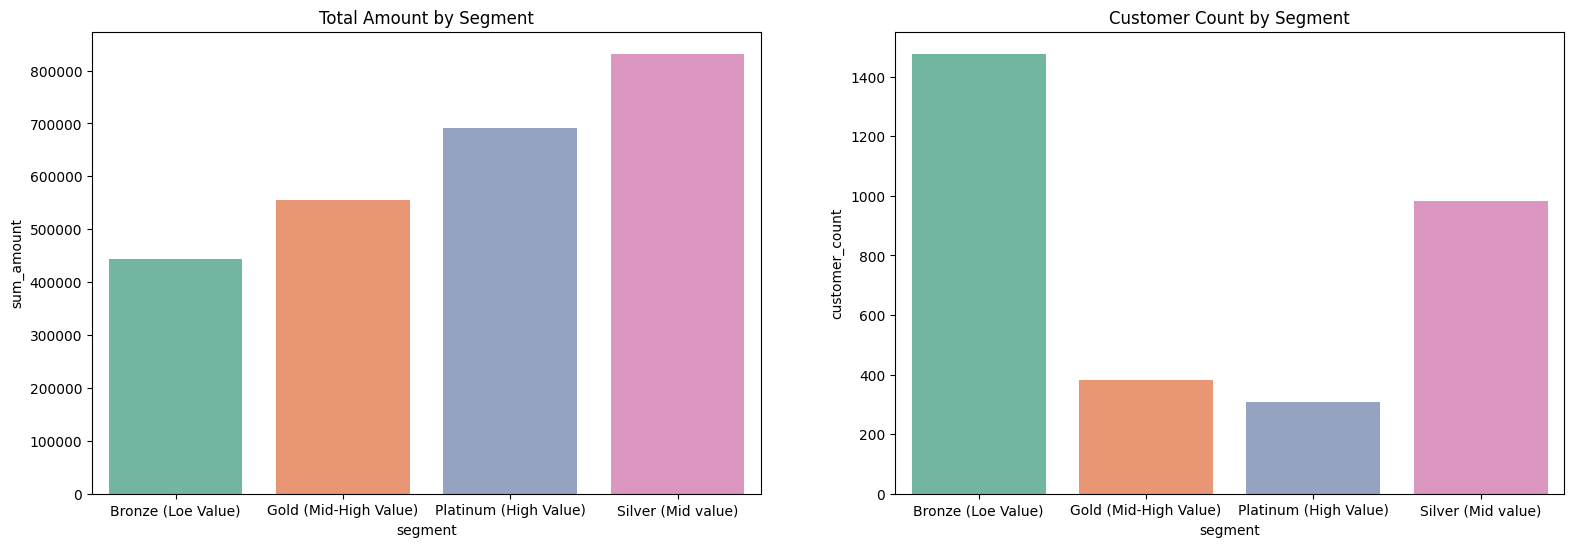

In [63]:
# #bar plot group_result
# plt.figure(figsize=(12,6))
# sns.barplot(data=group_result, x='segment', y='total_amount', palette='Set2')
# plt.title('Total Amount by Segment')
# #sight count by segment
# plt.figure(figsize=(12,6))
# sns.barplot(data=group_result, x='segment', y='customer_count', palette='Set2')
# plt.title('Customer Count by Segment')

#แก้ชื่อ
# group_result['segment'] = group_result['segment'].map(segmentation_map)

#ทำ subplot
fig, axes = plt.subplots(1, 2, figsize=(19, 6))  
sns.barplot(data=group_result, x='segment', y='sum_amount', palette='Set2', ax=axes[0])
axes[0].set_title('Total Amount by Segment')
sns.barplot(data=group_result, x='segment', y='customer_count', palette='Set2', ax=axes[1])
axes[1].set_title('Customer Count by Segment')

In [64]:
group_csid

,customer_id,total_amount,transaction_count,AVG_amount,LTVper2years,LTV,cluster,segment
0,10545,6798.30,5,1359.66,13596.60,2824.964199,2,Platinum (High Value)
1,12722,6328.17,3,2109.39,12656.34,2337.547085,2,Platinum (High Value)
2,11269,6213.55,4,1553.39,12427.12,5529.674655,2,Platinum (High Value)
3,12686,6148.01,5,1229.60,12296.00,5061.185573,2,Platinum (High Value)
4,11673,5448.35,4,1362.09,10896.72,5283.129011,2,Platinum (High Value)
...,...,...,...,...,...,...,...,...
3143,13343,1.76,1,1.76,3.52,0.000000,3,Bronze (Loe Value)
3144,12866,0.94,1,0.94,1.88,0.000000,3,Bronze (Loe Value)
3145,14574,0.28,1,0.28,0.56,0.000000,3,Bronze (Loe Value)
3146,10752,0.15,1,0.15,0.30,0.000000,3,Bronze (Loe Value)


#แปะ segment ใส่ df_trans

In [65]:
df_trans.head()

#merge
df_trans=pd.merge(df_trans, group_csid.reset_index()[['customer_id', 'segment']],right_on='customer_id', left_on='customer_id', how='left')


In [66]:
df_trans['segment'].unique().tolist()

['Silver (Mid value)',
 'Gold (Mid-High Value)',
 'Bronze (Loe Value)',
 'Platinum (High Value)']

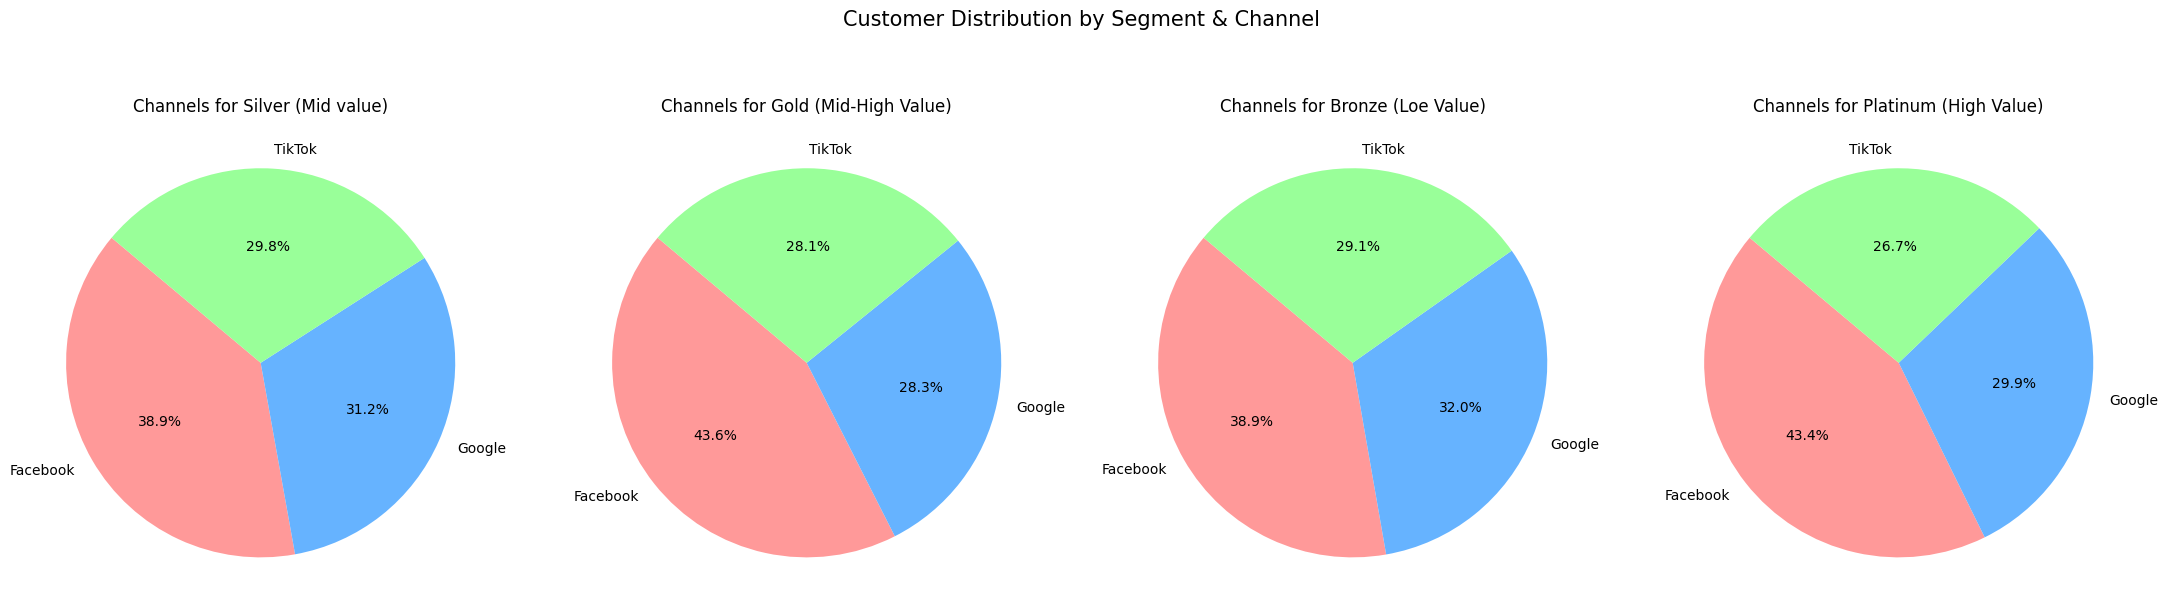

In [67]:
#make pie chart of channel by segment  ดูว่าช่องทางไหนที่ลูกค้าแต่ละกลุ่มอยู่มาก

import matplotlib.pyplot as plt

# 1. สร้างพื้นที่ 1 แถว 3 คอลัมน์
fig, axes = plt.subplots(1, 4, figsize=(22, 7))

# รายชื่อ Segment ที่เราจะวนลูปทำ
segments = df_trans['segment'].unique().tolist()
colors = ['#ff9999','#66b3ff','#99ff99'] # สีสำหรับแต่ละ Channel (Facebook, Google, TikTok)

for i, seg in enumerate(segments):
    # กรองข้อมูลเฉพาะ Segment นั้นๆ
    data = df_trans[df_trans['segment'] == seg].groupby('channel_origin').size()
    
    # พล็อตลงในช่อง (axes) ที่ i
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%', startangle=140, colors=colors)
    axes[i].set_title(f'Channels for {seg}')

# ใส่หัวข้อใหญ่ตรงกลาง
plt.suptitle('Customer Distribution by Segment & Channel', fontsize=15)
plt.tight_layout() # ปรับระยะห่างไม่ให้ตัวอักษรทับกัน
plt.show()

จาก pie-chart ข้างต้น เพื่อดูว่าลูกค้าในแต่ละ segment ใช้ช่องทางไหนในการใช้บริการ เป็นสัดส่วนเท่าไหร่

In [68]:
df_trans

,customer_id,order_date,amount,channel_origin,segment
0,13170,2025-10-06,329.409987,TikTok,Silver (Mid value)
1,13835,2025-12-07,1409.346934,Google,Gold (Mid-High Value)
2,12151,2025-11-24,173.840904,Facebook,Silver (Mid value)
3,11237,2025-06-16,268.673427,Google,Bronze (Loe Value)
4,13735,2025-05-02,773.130183,Facebook,Platinum (High Value)
...,...,...,...,...,...
4995,14879,2025-07-20,240.840504,Facebook,Bronze (Loe Value)
4996,12739,2025-02-21,521.463675,Google,Platinum (High Value)
4997,12730,2025-03-13,1694.776499,Facebook,Silver (Mid value)
4998,11318,2025-01-21,357.058159,Google,Bronze (Loe Value)


# CHURN RATE

In [69]:
#churn rate

lasted_transaction = df_trans['order_date'].max()

churn_rate = df_trans.groupby('customer_id')['order_date'].max().reset_index()
churn_rate['last_order_days'] =  (lasted_transaction - churn_rate['order_date']).dt.days


last_order_days = order สุดท้ายที่สั่ง จนถึง วันที่ ดึงข้อมูลมา

In [70]:
group_csid=pd.merge(group_csid ,churn_rate[['customer_id','last_order_days']], on='customer_id', how='left')

In [71]:
group_csid.groupby('segment').agg({'last_order_days':['mean','std']}).reset_index()

segment last_order_days            
                                    mean         std
0     Bronze (Loe Value)      184.649966  107.646503
1  Gold (Mid-High Value)      172.919060  108.391675
2  Platinum (High Value)      108.856678   81.767039
3     Silver (Mid value)      113.652396   84.815709

ดู Mean std ของระยะเวลาตาม segment เพื่อคำนวณ Chrn rate ตาม segment

In [72]:
# make churn rate by segment โดยทำ T F โดยอิงตาม Mean + std ของแต่ละ Segment
segment_means = group_csid.groupby('segment')['last_order_days'].mean()
thresholds = segment_means + group_csid.groupby('segment')['last_order_days'].std()

In [73]:
#ทำ churned column โดยเช็คว่า last_order_days มากกว่า threshold ของ segment นั้นๆ หรือไม่
group_csid['churned'] = group_csid.apply(lambda row: row['last_order_days'] > thresholds[row['segment']], axis=1)

Churn rate by segment
segment                churned
Bronze (Loe Value)     False      1165
                       True        312
Gold (Mid-High Value)  False       301
                       True         82
Platinum (High Value)  False       254
                       True         53
Silver (Mid value)     False       792
                       True        189
Name: count, dtype: int64


Text(0, 0.5, 'Percentage (%)')

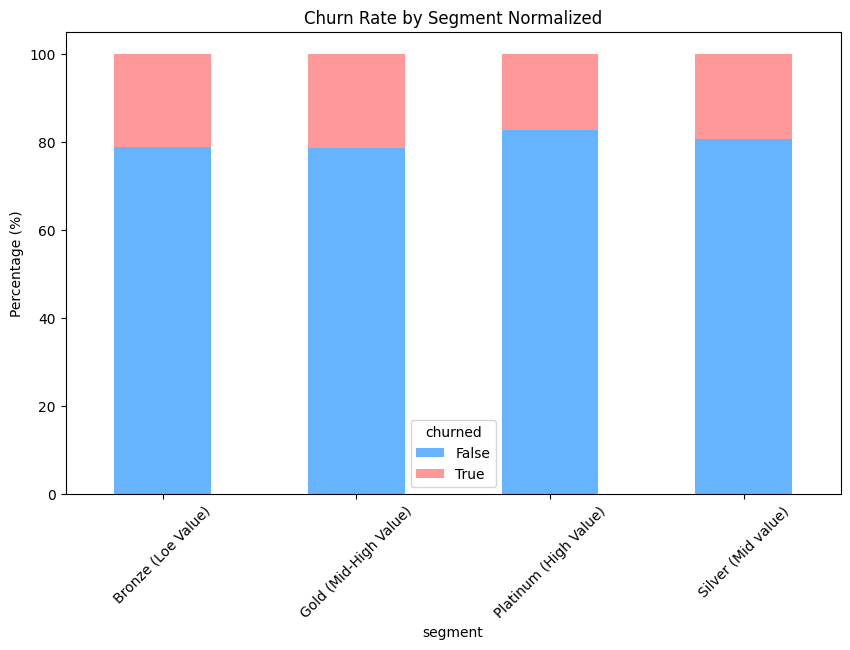

In [74]:
print('Churn rate by segment')
print(group_csid.groupby('segment')['churned'].value_counts())


#plot churn rate by segment
churn_rate_by_segment = group_csid.groupby('segment')['churned'].value_counts(normalize=True).unstack().fillna(0) * 100
churn_rate_by_segment.plot(kind='bar', stacked=True, figsize=(10,6), color=['#66b3ff','#ff9999'])
plt.title('Churn Rate by Segment Normalized')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')

In [75]:
from pymc_marketing.clv import BetaGeoModel

ปรึกษา gemini แนะนำให้ลองมาใช้ betaGeomodel

BetaGeoModel (BG/NBD) คืออะไร?

บรรทัดที่คุณเขียน BetaGeoModel(...) คือพระเอกของงานครับ มันคือโมเดลคณิตศาสตร์ที่เชื่อว่า:

    ขณะที่ยังมีชีวิต: ลูกค้าจะมาซื้อซ้ำแบบสุ่ม (Poisson Process)

    การตาย (Churn): ลูกค้ามีโอกาส "เลิกเป็นลูกค้า" ได้ทุกเมื่อ (Dropout) หลังจากจบการซื้อแต่ละครั้ง

    ความล้ำของมัน: มันสามารถแยกได้ว่า ลูกค้าที่หายไปนานๆ คือคนที่ "แค่ยังไม่ถึงรอบซื้อ" หรือ "ตาย (Churn) ไปแล้วจริงๆ" โดยดูจากพฤติกรรมในอดีตของเขาครับ

In [76]:
#prep data [ recency, frequency, T ] 
# recency = ระยะเวลาระหว่างการสั่งซื้อครั้งแรกและครั้งล่าสุดของลูกค้า
# frequency = จำนวนครั้งที่ลูกค้าทำการสั่งซื้อ (นับเฉพาะครั้งที่สองขึ้นไป)
# T = ระยะเวลาระหว่างการสั่งซื้อครั้งแรกของลูกค้าจนถึงวันที่วิเคราะห์ข้อมูล (หรือวันที่สิ้นสุดการสั่งซื้อครั้งล่าสุด)
 
df_churn_modelM = df_trans.groupby('customer_id').agg(
    recency = ('order_date', lambda x: (x.max() - x.min()).days),
    frequency = ('customer_id',lambda x : x.count() - 1 ),
    T = ('order_date', lambda x: (df_trans['order_date'].max() - x.min()).days)
)

In [77]:
from pymc_marketing.clv.utils import rfm_summary

# df_churn_model_auto = rfm_summary(df_trans,
#                 customer_id_col='customer_id',
#                 datetime_col='order_date',
#                 monetary_value_col='amount',
#                 observation_period_end=df_trans['order_date'].max()
#            )

ใช้ MAP: คุณได้ "คำตอบเดียว" ที่ดีที่สุด (Point Estimate) แต่มันจะไม่บอก "ความไม่แน่นอน" (Uncertainty) ว่าโมเดลมั่นใจแค่ไหน

ใช้ (MCMC): คุณจะได้ช่วงความเชื่อมั่น (Confidence Interval) ที่ละเอียดกว่ามาก แต่นั่นแหละครับ... รอนานจนกาแฟหมดแก้ว

ใช้เวลานานเกินไป จึงต้องใช้ 'map'

In [78]:
model_churn = BetaGeoModel(data=df_churn_model_auto)
model_churn.fit(fit_method='map')
model_churn.expected_probability_alive()

Output()

<xarray.DataArray 'frequency' (chain: 1, draw: 1, customer_id: 3148)> Size: 25kB
array([[[1., 1., 1., ..., 1., 1., 1.]]], shape=(1, 1, 3148))
Coordinates:
  * chain        (chain) int64 8B 0
  * draw         (draw) int64 8B 0
  * customer_id  (customer_id) int32 13kB 10001 10002 10004 ... 14996 14997

In [79]:
print(model_churn.fit_result)

<xarray.Dataset> Size: 64B
Dimensions:        (chain: 1, draw: 1)
Coordinates:
  * chain          (chain) int64 8B 0
  * draw           (draw) int64 8B 0
Data variables:
    alpha          (chain, draw) float64 8B 89.86
    phi_dropout    (chain, draw) float64 8B 0.4299
    kappa_dropout  (chain, draw) float64 8B 21.24
    r              (chain, draw) float64 8B 0.4572
    a              (chain, draw) float64 8B 9.134
    b              (chain, draw) float64 8B 12.11
Attributes:
    created_at:                 2026-03-03T13:03:42.547679+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.0


คำแปล

1. กลุ่ม "การซื้อซ้ำ" (r และ alpha)

สองตัวนี้จะบอกว่าลูกค้า "ขยัน" ซื้อแค่ไหน

    r (0.4572): คือความหลากหลายของพฤติกรรมลูกค้า ยิ่งค่าน้อย (ต่ำกว่า 1) แปลว่าลูกค้าคุณ "มีความต่างกันสูงมาก" บางคนซื้อบ่อยเว่อร์ แต่ส่วนใหญ่ซื้อนานๆ ครั้ง

    alpha (89.86): คือ "จังหวะ" การซื้อโดยเฉลี่ย ค่าที่สูงเกือบ 90 นี้ บอกว่าลูกค้าส่วนใหญ่มีรอบการซื้อที่ "ค่อนข้างห่าง" (ไม่ได้ซื้อทุกวันหรือทุกสัปดาห์)

2. กลุ่ม "การเลิกเป็นลูกค้า" (a และ b)

สองตัวนี้บอกว่าลูกค้า "ถอดใจ" หรือ Churn ง่ายแค่ไหน

    a (9.134) และ b (12.11): สองค่านี้ทำงานคู่กันเพื่อสร้างกราฟความน่าจะเป็นในการเลิกซื้อ

    คำแปล: เนื่องจากค่า b>a แปลว่าลูกค้าของคุณส่วนใหญ่ "ยังมีใจให้ธุรกิจคุณอยู่" ไม่ได้ซื้อปุ๊บแล้วหายสาบสูญไปทันที (Dropout) พวกเขามีความซื่อสัตย์ (Loyalty) ในระดับที่ค่อนข้างดีครับ

3. ตัววัดความเสี่ยง (phi_dropout)

    phi_dropout (0.4299): ตัวนี้แหละสำคัญมาก! มันคือ "โอกาสที่ลูกค้าจะ Churn ทันทีหลังจากซื้อครั้งแรก"

    แปลผล: ประมาณ 43% ของลูกค้าใหม่ที่เข้ามา มีความเสี่ยงที่จะซื้อครั้งเดียวแล้ว "โบกมือลา" ทันที นี่คือโจทย์ใหญ่ที่คุณต้องไปทำโปรโมชั่น "ต้อนรับ" เพื่อรั้งคนกลุ่มนี้ไม่ให้หายไปครับ



r = ความชันของ Gamma Distribution 
a & b = Beta Distribution b ดึงดูดให้อยู่ต่อ  a ดึงออกให้ churn

phi_dropout = บอกถึงลูกค้าใหม่ที่เข้ามา [ตัวแปรนี้เป็นตัวเสริมใน pymc_marketing ที่ช่วยแยกแยะ "อาการหน้ามืด" ของลูกค้าใหม่ครับ

    หลักการ: มันคือสัดส่วน (Zero-inflation) ที่โมเดลใส่ไว้ดักพวก "One-hit Wonder"

    ทำไม: ค่า 0.430 หมายความว่าจากลูกค้า 100 คนที่เดินเข้ามาซื้อครั้งแรก มี 43 คนที่ "ไม่ได้ตั้งใจจะอยู่ยาวตั้งแต่แรก" (อาจจะมาเพราะโปรแรงๆ ครั้งเดียวจบ) โมเดลเลยแยกกลุ่มนี้ออกมาจากกลุ่มปกติ เพื่อไม่ให้ไปดึงค่า Loyalty ของกลุ่มหลักครับ]

In [80]:
# ดึงค่า probability จากโมเดลมาใส่ในตารางหลัก
# .values[0, 0, :] คือการดึงข้อมูลจาก chain ที่ 1 และ draw ที่ 1 ออกมา
df_churn_model_auto['p_alive'] = model_churn.expected_probability_alive().values[0, 0, :]


ทำการ join เข้าสู่ตาราง group_csid

In [81]:
group_csid = pd.merge(group_csid , df_churn_model_auto[['customer_id', 'p_alive']], on='customer_id', how='left')
group_csid.rename(columns={
    'p_alive':'probability_alive'}, inplace=True)
group_csid['probability_alive'] = round(group_csid['probability_alive'],ndigits=2)

In [82]:
df_churn_model_auto

,customer_id,frequency,recency,T,monetary_value,frequency_plus_one,LTV,p_alive
0,10001,0.0,0.0,277.0,0.000000,1.0,0.000000,1.000000
1,10002,0.0,0.0,322.0,0.000000,1.0,0.000000,1.000000
2,10004,0.0,0.0,22.0,0.000000,1.0,0.000000,1.000000
3,10007,0.0,0.0,272.0,0.000000,1.0,0.000000,1.000000
4,10011,0.0,0.0,216.0,0.000000,1.0,0.000000,1.000000
...,...,...,...,...,...,...,...,...
3143,14992,1.0,5.0,139.0,432.822615,2.0,334.235242,0.268692
3144,14994,3.0,263.0,310.0,278.808408,4.0,960.340072,0.500656
3145,14995,0.0,0.0,169.0,0.000000,1.0,0.000000,1.000000
3146,14996,0.0,0.0,284.0,0.000000,1.0,0.000000,1.000000


เปรียบเทียบกับ อัตราการ churn แบบ T F ข้างต้นว่าเป็นอย่างไร 

                 segment probability_alive          
                                      mean       std
0     Bronze (Loe Value)          1.000000  0.000000
1  Gold (Mid-High Value)          0.965248  0.139790
2  Platinum (High Value)          0.402052  0.138338
3     Silver (Mid value)          0.403853  0.125187


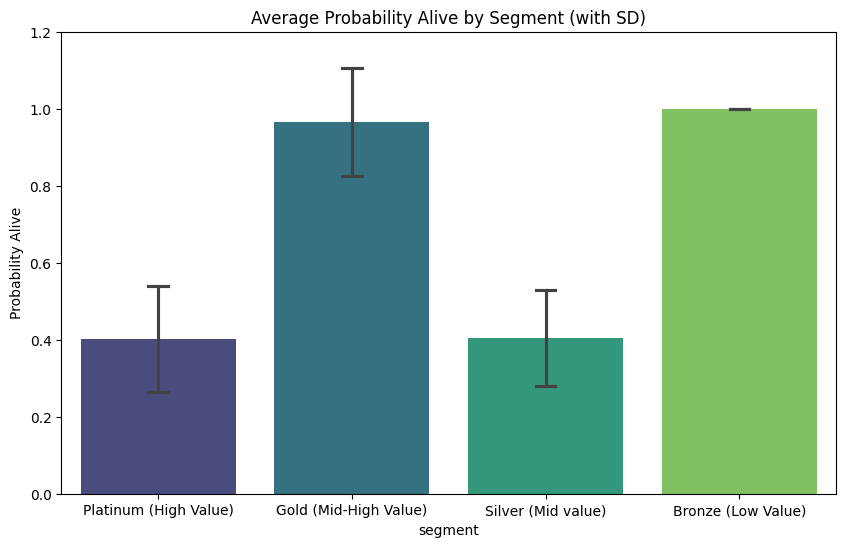

In [94]:
# plot probability alive by segment
print(group_csid.groupby('segment').agg({'probability_alive':['mean','std']}).reset_index())
group_csid['segment'] = group_csid['segment'].str.replace('Loe', 'Low')

# 2. Plot ด้วย Seaborn แบบตัวเดียวจบ
plt.figure(figsize=(10,6))
sns.barplot(
    data=group_csid, 
    x='segment', 
    y='probability_alive', 
    hue='segment',      # ใส่ hue เพื่อลด FutureWarning
    palette='viridis',
    errorbar='sd',      # สั่งให้วาด Error Bar จากค่า Standard Deviation (std) เอง
    capsize=0.1,        # ใส่หัวปิดท้ายให้เส้น Error Bar
    legend=False
)

plt.title('Average Probability Alive by Segment (with SD)')
plt.ylabel('Probability Alive')
plt.ylim(0, 1.2)        # เผื่อที่ด้านบนให้เห็น Error Bar ชัดๆ
plt.show()


In [84]:
#filter probability alive < 0.3 & 'churned' == false
filtered_customers_alert = group_csid[(group_csid['probability_alive'] < 0.3) & (group_csid['churned'] == False) ]
print(filtered_customers_alert.describe()) #แสดงลูกค้าที่มีความเสี่ยงที่จะ churn แต่ยังไม่ churn ในตอนนี้ เสี่ยงสูง
filtered_customers_alert.groupby('segment').agg({'customer_id':'count'})     

        customer_id  total_amount  transaction_count   AVG_amount  \
count     88.000000     88.000000          88.000000    88.000000   
mean   12659.488636   1446.821364           2.670455   539.385341   
std     1402.704080    916.780575           0.812568   305.476969   
min    10082.000000     86.750000           2.000000    43.380000   
25%    11518.000000    732.600000           2.000000   329.790000   
50%    12800.000000   1243.680000           2.000000   494.975000   
75%    13786.500000   1965.632500           3.000000   661.805000   
max    14992.000000   4901.990000           5.000000  1634.000000   

       LTVper2years          LTV    cluster  last_order_days  \
count     88.000000    88.000000  88.000000        88.000000   
mean    2893.642955   850.891695   1.250000       161.659091   
std     1833.562328   740.371693   0.508548        26.639736   
min      173.520000     5.665787   0.000000        67.000000   
25%     1465.180000   283.292510   1.000000       147.5000

,customer_id
segment,
Gold (Mid-High Value),3
Platinum (High Value),25
Silver (Mid value),60


Action plant to segment Alert

In [85]:
#customer ID ที่มีความเสี่ยงสูงที่จะ churn แต่ยังไม่ churn ในตอนนี้
filtered_customers_alert[['segment' , 'customer_id','total_amount']].sort_values(by=['segment', 'total_amount'], ascending= (True , False))

# export filtered customers to csv
filtered_customers_alert.to_csv('filtered_customers_alert.csv', index=False)


In [86]:
# สิ่งที่ควรเติมในข้อมูล (Data Augmentation)

#     Retention Rate: คำนวณอัตราการกลับมาซื้อซ้ำแบบ Cohort Analysis จะทำให้โปรเจกต์ดู Advance ขึ้นมาก

#     RFM Score: แม้จะทำ K-Means แล้ว แต่การแสดงตาราง RFM (Recency, Frequency, Monetary) ที่เป็นมาตรฐานสากลจะช่วยให้คนสาย Marketing เข้าใจสิ่งที่คุณทำได้ง่ายขึ้นครับ

# สรุป: โค้ดคุณ "ทำงานได้" (Functional) แล้ว แต่ขาดการ "เล่าเรื่อง" (Narrative) ครับ ถ้าเติมเรื่องการแปลความหมายทางธุรกิจและการใช้ Visualization พอร์ตนี้จะแข็งแกร่งมากครับ!

## For fix report

In [87]:
# plot trend revenue & spend by date power bi

revenue_spend = df_trans.groupby(df_trans['order_date'].dt.to_period('M'))['amount'].sum().reset_index()
A=df_spend.groupby(df_spend['date'].dt.to_period('M'))['spend'].sum().reset_index()

#pd.merge(revenue_spend, A, left_on='order_date', right_on='date', how='left').drop(columns=['date']).rename(columns={'amount':'revenue','spend':'spend'}).to_csv('revenue_spend_by_month.csv', index=False)


In [88]:
df_churn_model_auto=df_churn_model_auto.merge(group_csid[['customer_id','segment']], on='customer_id', how='left')


In [89]:
df_churn_model_auto

,customer_id,frequency,recency,T,monetary_value,frequency_plus_one,LTV,p_alive,segment
0,10001,0.0,0.0,277.0,0.000000,1.0,0.000000,1.000000,Bronze (Loe Value)
1,10002,0.0,0.0,322.0,0.000000,1.0,0.000000,1.000000,Bronze (Loe Value)
2,10004,0.0,0.0,22.0,0.000000,1.0,0.000000,1.000000,Bronze (Loe Value)
3,10007,0.0,0.0,272.0,0.000000,1.0,0.000000,1.000000,Bronze (Loe Value)
4,10011,0.0,0.0,216.0,0.000000,1.0,0.000000,1.000000,Bronze (Loe Value)
...,...,...,...,...,...,...,...,...,...
3143,14992,1.0,5.0,139.0,432.822615,2.0,334.235242,0.268692,Silver (Mid value)
3144,14994,3.0,263.0,310.0,278.808408,4.0,960.340072,0.500656,Silver (Mid value)
3145,14995,0.0,0.0,169.0,0.000000,1.0,0.000000,1.000000,Bronze (Loe Value)
3146,14996,0.0,0.0,284.0,0.000000,1.0,0.000000,1.000000,Gold (Mid-High Value)


In [90]:
ltv_results = df_churn_model_auto.groupby('segment').agg({'LTV':['mean','std','median','min','max']}).reset_index()
ltv_results.columns = ['segment', 'LTV_mean', 'LTV_std', 'LTV_median', 'LTV_min', 'LTV_max']

In [91]:
ltv_results

,segment,LTV_mean,LTV_std,LTV_median,LTV_min,LTV_max
0,Bronze (Loe Value),0.000000,0.000000,0.000000,0.000000,0.000000
1,Gold (Mid-High Value),31.036956,145.025138,0.000000,0.000000,1138.038192
2,Platinum (High Value),2038.745254,889.253689,1785.180563,815.230898,6072.082381
3,Silver (Mid value),475.764125,359.677979,400.428692,0.000000,1518.879312


C:\Users\patta\AppData\Local\Temp\ipykernel_9312\491317320.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data= ltv_results , x = 'segment', y = 'LTV_mean', palette='viridis')


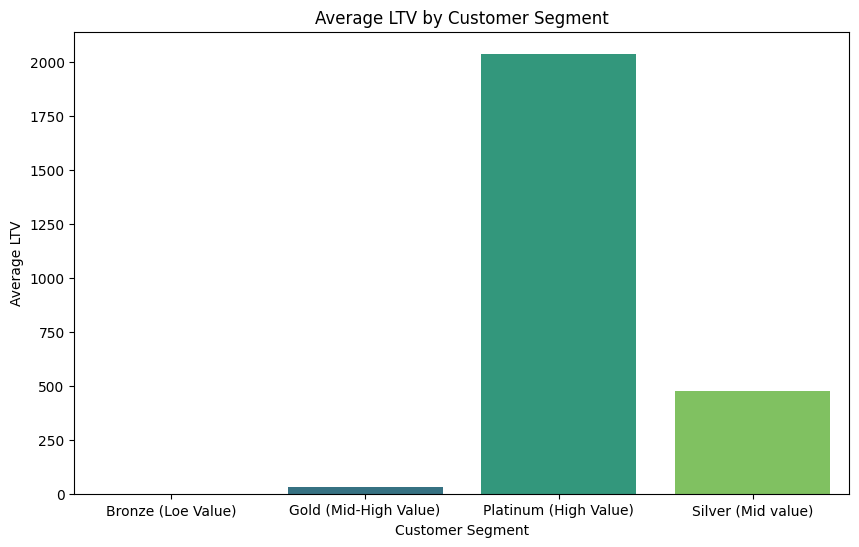

In [92]:
#plot ltv by segment
plt.figure(figsize=(10,6))
sns.barplot( data= ltv_results , x = 'segment', y = 'LTV_mean', palette='viridis')
plt.title('Average LTV by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average LTV')
#add error bar
plt.show()

In [93]:
ltv_results

,segment,LTV_mean,LTV_std,LTV_median,LTV_min,LTV_max
0,Bronze (Loe Value),0.000000,0.000000,0.000000,0.000000,0.000000
1,Gold (Mid-High Value),31.036956,145.025138,0.000000,0.000000,1138.038192
2,Platinum (High Value),2038.745254,889.253689,1785.180563,815.230898,6072.082381
3,Silver (Mid value),475.764125,359.677979,400.428692,0.000000,1518.879312
